# Transformer (custom) — Ajuste único + walk-forward en 1, 7 y 30 días

Un solo modelo Transformer single-step entrenado. Horizonte 1 día evaluado directamente (walk-forward diario). Horizontes 7 y 30 días vía forecast recursivo en bloques, reutilizando el mismo modelo entrenado.

In [1]:
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import time
import math
import random
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, median_absolute_error, max_error

SEED = 333
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.mps.manual_seed(SEED)
torch.backends.cudnn.deterministic = True

# Parámetros
input_window = 30      # días de contexto
output_window = 1      # predicción de 1 día (autoregresivo)
batch_size = 64
device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")
print(f"Device: {device}")

# Carga de datos
df = pd.read_parquet('../../data/processed/dataset_consolidado.parquet')

train_data = df[df.index < '2025-08-01']['precio_bolsa']
test_data = df[(df.index >= '2025-08-01') & (df.index <= '2026-07-31')]['precio_bolsa']

print(f"Train: {len(train_data)} días")
print(f"Test: {len(test_data)} días")

Device: mps
Train: 4595 días
Test: 365 días


In [2]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
train_scaled = scaler.fit_transform(train_data.values.reshape(-1, 1)).flatten()
test_scaled = scaler.transform(test_data.values.reshape(-1, 1)).flatten()

print(f"Train escalado: media={train_scaled.mean():.3f}, std={train_scaled.std():.3f}")
print(f"Test escalado: media={test_scaled.mean():.3f}, std={test_scaled.std():.3f}")

Train escalado: media=-0.000, std=1.000
Test escalado: media=0.178, std=0.799


In [3]:
class PositionalEncoding(nn.Module):
    def __init__(self, d_model, max_len=5000):
        super(PositionalEncoding, self).__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        pe = pe.unsqueeze(0).transpose(0, 1)
        self.register_buffer('pe', pe)

    def forward(self, x):
        return x + self.pe[:x.size(0), :]


class TransAm(nn.Module):
    def __init__(self, feature_size=250, num_layers=1, dropout=0.1):
        super(TransAm, self).__init__()
        self.model_type = 'Transformer'
        self.src_mask = None
        self.pos_encoder = PositionalEncoding(feature_size)
        self.encoder_layer = nn.TransformerEncoderLayer(d_model=feature_size, nhead=10, dropout=dropout)
        self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)
        self.decoder = nn.Linear(feature_size, 1)
        self.init_weights()

    def init_weights(self):
        initrange = 0.1
        self.decoder.bias.data.zero_()
        self.decoder.weight.data.uniform_(-initrange, initrange)

    def forward(self, src):
        if self.src_mask is None or self.src_mask.size(0) != len(src):
            device = src.device
            mask = self._generate_square_subsequent_mask(len(src)).to(device)
            self.src_mask = mask
        src = self.pos_encoder(src)
        output = self.transformer_encoder(src, self.src_mask)
        output = self.decoder(output)
        return output

    def _generate_square_subsequent_mask(self, sz):
        mask = (torch.triu(torch.ones(sz, sz)) == 1).transpose(0, 1)
        mask = mask.float().masked_fill(mask == 0, float('-inf')).masked_fill(mask == 1, float(0.0))
        return mask

In [4]:
def create_inout_sequences(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L - tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+output_window:i+tw+output_window]
        inout_seq.append((train_seq, train_label))
    return torch.FloatTensor(np.array(inout_seq))

def get_batch(source, i, bs):
    seq_len = min(bs, len(source) - 1 - i)
    data = source[i:i+seq_len]
    input = torch.stack(torch.stack([item[0] for item in data]).chunk(input_window, 1))
    target = torch.stack(torch.stack([item[1] for item in data]).chunk(input_window, 1))
    return input, target


train_sequences = create_inout_sequences(train_scaled, input_window)
train_sequences = train_sequences[:-output_window].to(device)

print(f"Secuencias de entrenamiento: {train_sequences.shape}")

Secuencias de entrenamiento: torch.Size([4564, 2, 30])


In [5]:
def train_epoch(train_data):
    model.train()
    total_loss = 0.
    for batch, i in enumerate(range(0, len(train_data) - 1, batch_size)):
        data, targets = get_batch(train_data, i, batch_size)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 0.7)
        optimizer.step()
        total_loss += loss.item()
    return total_loss / (batch + 1)

In [6]:
model = TransAm(feature_size=250, num_layers=1, dropout=0.1).to(device)

criterion = nn.MSELoss()
lr = 0.00005
optimizer = torch.optim.AdamW(model.parameters(), lr=lr)
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, 1.0, gamma=0.95)

epochs = 150

print("Entrenando Transformer...")
for epoch in range(1, epochs + 1):
    epoch_start = time.time()
    loss = train_epoch(train_sequences)
    if epoch % 10 == 0 or epoch == epochs:
        print(f"| epoch {epoch:3d}/{epochs} | loss {loss:.7f} | time {time.time()-epoch_start:.2f}s")
    scheduler.step()

print("Entrenamiento completo")

/var/folders/vz/dknzsyq13c55x4nb5c75hmn40000gn/T/ipykernel_1394/3406580392.py:23: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.self_attn.batch_first was not True(use batch_first for better inference performance)
  self.transformer_encoder = nn.TransformerEncoder(self.encoder_layer, num_layers=num_layers)


Entrenando Transformer...
| epoch  10/150 | loss 0.1108286 | time 0.51s
| epoch  20/150 | loss 0.0861186 | time 0.50s
| epoch  30/150 | loss 0.0775368 | time 0.50s
| epoch  40/150 | loss 0.0742990 | time 0.50s
| epoch  50/150 | loss 0.0688518 | time 0.50s
| epoch  60/150 | loss 0.0679734 | time 0.50s
| epoch  70/150 | loss 0.0684212 | time 0.50s
| epoch  80/150 | loss 0.0674092 | time 0.50s
| epoch  90/150 | loss 0.0674774 | time 0.50s
| epoch 100/150 | loss 0.0679849 | time 0.50s
| epoch 110/150 | loss 0.0672689 | time 0.50s
| epoch 120/150 | loss 0.0675724 | time 0.50s
| epoch 130/150 | loss 0.0664900 | time 0.50s
| epoch 140/150 | loss 0.0672225 | time 0.50s
| epoch 150/150 | loss 0.0667069 | time 0.50s
Entrenamiento completo


## Horizonte 1 día — evaluación directa (walk-forward diario, contexto siempre real)

In [7]:
combined_scaled = np.concatenate([train_scaled[-input_window:], test_scaled])
test_sequences = create_inout_sequences(combined_scaled, input_window)
test_sequences = test_sequences[:-output_window].to(device)

print(f"Secuencias de test (walk-forward diario): {test_sequences.shape}")

def forecast_walk_forward(model, sequences):
    model.eval()
    predicciones = torch.Tensor(0)
    with torch.no_grad():
        for i in range(0, len(sequences) - 1):
            data, target = get_batch(sequences, i, 1)
            output = model(data)
            predicciones = torch.cat((predicciones, output[-1].view(-1).cpu()), 0)
    return predicciones.numpy()

print("Generando forecast walk-forward (1 día)...")
pred_scaled_1d = forecast_walk_forward(model, test_sequences)

pred_1d = scaler.inverse_transform(pred_scaled_1d.reshape(-1, 1)).flatten()
fechas_pred_1d = test_data.index[:len(pred_1d)]
real_1d = test_data.loc[fechas_pred_1d].values

mae_1d = mean_absolute_error(real_1d, pred_1d)
rmse_1d = np.sqrt(mean_squared_error(real_1d, pred_1d))
mape_1d = np.mean(np.abs((real_1d - pred_1d) / real_1d)) * 100

print(f"Horizonte 1 día — MAE: {mae_1d:.2f} | RMSE: {rmse_1d:.2f} | MAPE: {mape_1d:.2f}%")

Secuencias de test (walk-forward diario): torch.Size([364, 2, 30])
Generando forecast walk-forward (1 día)...
Horizonte 1 día — MAE: 43.15 | RMSE: 61.40 | MAPE: 14.44%


## Horizontes 7 y 30 días — forecast recursivo en bloques (walk-forward)

In [8]:
def forecast_block(model, contexto_scaled, pasos):
    """Genera 'pasos' predicciones de forma recursiva (autoregresiva) dentro de un bloque."""
    model.eval()
    serie = list(contexto_scaled[-input_window:])
    predicciones = []
    with torch.no_grad():
        for _ in range(pasos):
            seq = np.array(serie[-input_window:], dtype=np.float32)
            seq_t = torch.from_numpy(seq).view(input_window, 1, 1).to(device)
            output = model(seq_t)
            pred = output[-1].item()
            predicciones.append(pred)
            serie.append(pred)
    return predicciones


def walk_forward_bloques(model, train_scaled, test_data, test_scaled, pasos):
    predicciones = []
    fechas_pred = []
    serie_actual = list(train_scaled)

    for i in range(0, len(test_data), pasos):
        pasos_bloque = min(pasos, len(test_data) - i)
        contexto = np.array(serie_actual[-input_window:])

        block_pred = forecast_block(model, contexto, pasos_bloque)

        predicciones.extend(block_pred)
        fechas_pred.extend(test_data.index[i:i+pasos_bloque])

        real_bloque_scaled = test_scaled[i:i+pasos_bloque]
        serie_actual.extend(real_bloque_scaled.tolist())

    pred_original = scaler.inverse_transform(np.array(predicciones).reshape(-1, 1)).flatten()
    return pd.Series(pred_original, index=fechas_pred)

In [9]:
def encontrar_raiz_repo(marcador='.git'):
    actual = Path.cwd()
    while actual != actual.parent:
        if (actual / marcador).exists():
            return actual
        actual = actual.parent
    raise FileNotFoundError("No se encontró la raíz del repo")


def agregar_metricas(nombre, real, pred, archivo, horizonte):
    real = np.array(real)
    pred = np.array(pred)
    mae = np.mean(np.abs(real - pred))
    rmse = np.sqrt(np.mean((real - pred)**2))
    mape = np.mean(np.abs((real - pred) / real)) * 100
    smape = np.mean(2 * np.abs(real - pred) / (np.abs(real) + np.abs(pred))) * 100
    r2 = r2_score(real, pred)
    medae = median_absolute_error(real, pred)
    max_err = max_error(real, pred)
    sesgo = np.mean(pred - real)

    nueva_fila = pd.DataFrame([{
        'Modelo': nombre,
        'Horizonte': horizonte,
        'MAE': round(mae, 2),
        'RMSE': round(rmse, 2),
        'MAPE (%)': round(mape, 2),
        'sMAPE (%)': round(smape, 2),
        'R²': round(r2, 4),
        'MedAE': round(medae, 2),
        'MaxError': round(max_err, 2),
        'Sesgo': round(sesgo, 2)
    }])

    if archivo.exists():
        tabla = pd.read_parquet(archivo)
        tabla = tabla[~((tabla['Modelo'] == nombre) & (tabla['Horizonte'] == horizonte))]
        tabla = pd.concat([tabla, nueva_fila], ignore_index=True)
    else:
        tabla = nueva_fila

    tabla.to_parquet(archivo, index=False)
    print(f"'{nombre}' (horizonte={horizonte}d) guardado en {archivo}")
    return tabla


raiz = encontrar_raiz_repo()
archivo_tabla = raiz / 'data' / 'processed' / 'tabla_metricas.parquet'
print("Archivo de métricas:", archivo_tabla)

Archivo de métricas: /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


In [10]:
agregar_metricas('Transformer', real_1d, pred_1d, archivo_tabla, horizonte=1)

'Transformer' (horizonte=1d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


,Modelo,Horizonte,MAE,RMSE,MAPE (%),sMAPE (%),R²,MedAE,MaxError,Sesgo
0,"SARIMA(1,0,1)(1,0,1,7)",1,37.69,54.29,13.02,12.82,0.9342,26.82,276.52,-5.10
1,"SARIMA(2, 0, 2)(1, 0, 1, 7)",1,37.58,54.20,12.97,12.77,0.9344,26.23,277.91,-5.01
2,"SARIMAX(2,0,2)(1,0,1,7)",1,40.30,58.92,14.03,14.09,0.9225,26.23,332.33,-2.94
3,"SARIMA(1,0,1)(1,0,1,7)",7,64.28,91.51,21.33,21.09,0.8130,44.67,545.09,-12.39
4,"SARIMA(2, 0, 2)(1, 0, 1, 7)",7,64.04,91.06,21.30,21.00,0.8149,44.51,543.74,-11.81
5,"SARIMAX(2,0,2)(1,0,1,7)",7,56.65,79.27,19.23,19.74,0.8597,40.85,293.12,-4.37
6,"SARIMA(1,0,1)(1,0,1,7)",30,115.00,156.19,41.19,37.79,0.4554,88.01,583.55,-37.42
7,"SARIMA(2, 0, 2)(1, 0, 1, 7)",30,114.67,155.20,41.40,37.85,0.4622,88.77,581.97,-35.72
8,"SARIMAX(2,0,2)(1,0,1,7)",30,74.53,105.00,26.72,26.63,0.7539,53.30,424.28,-21.55
9,LSTM,1,43.36,59.65,15.69,15.04,0.9206,31.34,275.97,0.10


In [11]:
resultados_horizonte = {1: pd.Series(pred_1d, index=fechas_pred_1d)}

for horizonte in [7, 30]:
    print(f"\n{'='*60}\nHorizonte: {horizonte} día(s)\n{'='*60}")
    pred = walk_forward_bloques(model, train_scaled, test_data, test_scaled, pasos=horizonte)
    real_alineado = test_data.loc[pred.index]

    mae = np.mean(np.abs(real_alineado - pred))
    rmse = np.sqrt(np.mean((real_alineado - pred)**2))
    mape = np.mean(np.abs((real_alineado - pred) / real_alineado)) * 100
    print(f"Transformer ({horizonte}d): MAE={mae:.2f} | RMSE={rmse:.2f} | MAPE={mape:.2f}%")

    agregar_metricas('Transformer', real_alineado, pred, archivo_tabla, horizonte)
    resultados_horizonte[horizonte] = pred


Horizonte: 7 día(s)
Transformer (7d): MAE=77.35 | RMSE=109.49 | MAPE=25.39%
'Transformer' (horizonte=7d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet

Horizonte: 30 día(s)
Transformer (30d): MAE=140.78 | RMSE=187.20 | MAPE=48.24%
'Transformer' (horizonte=30d) guardado en /Users/maguverm/Documents/tesis-bolsa/data/processed/tabla_metricas.parquet


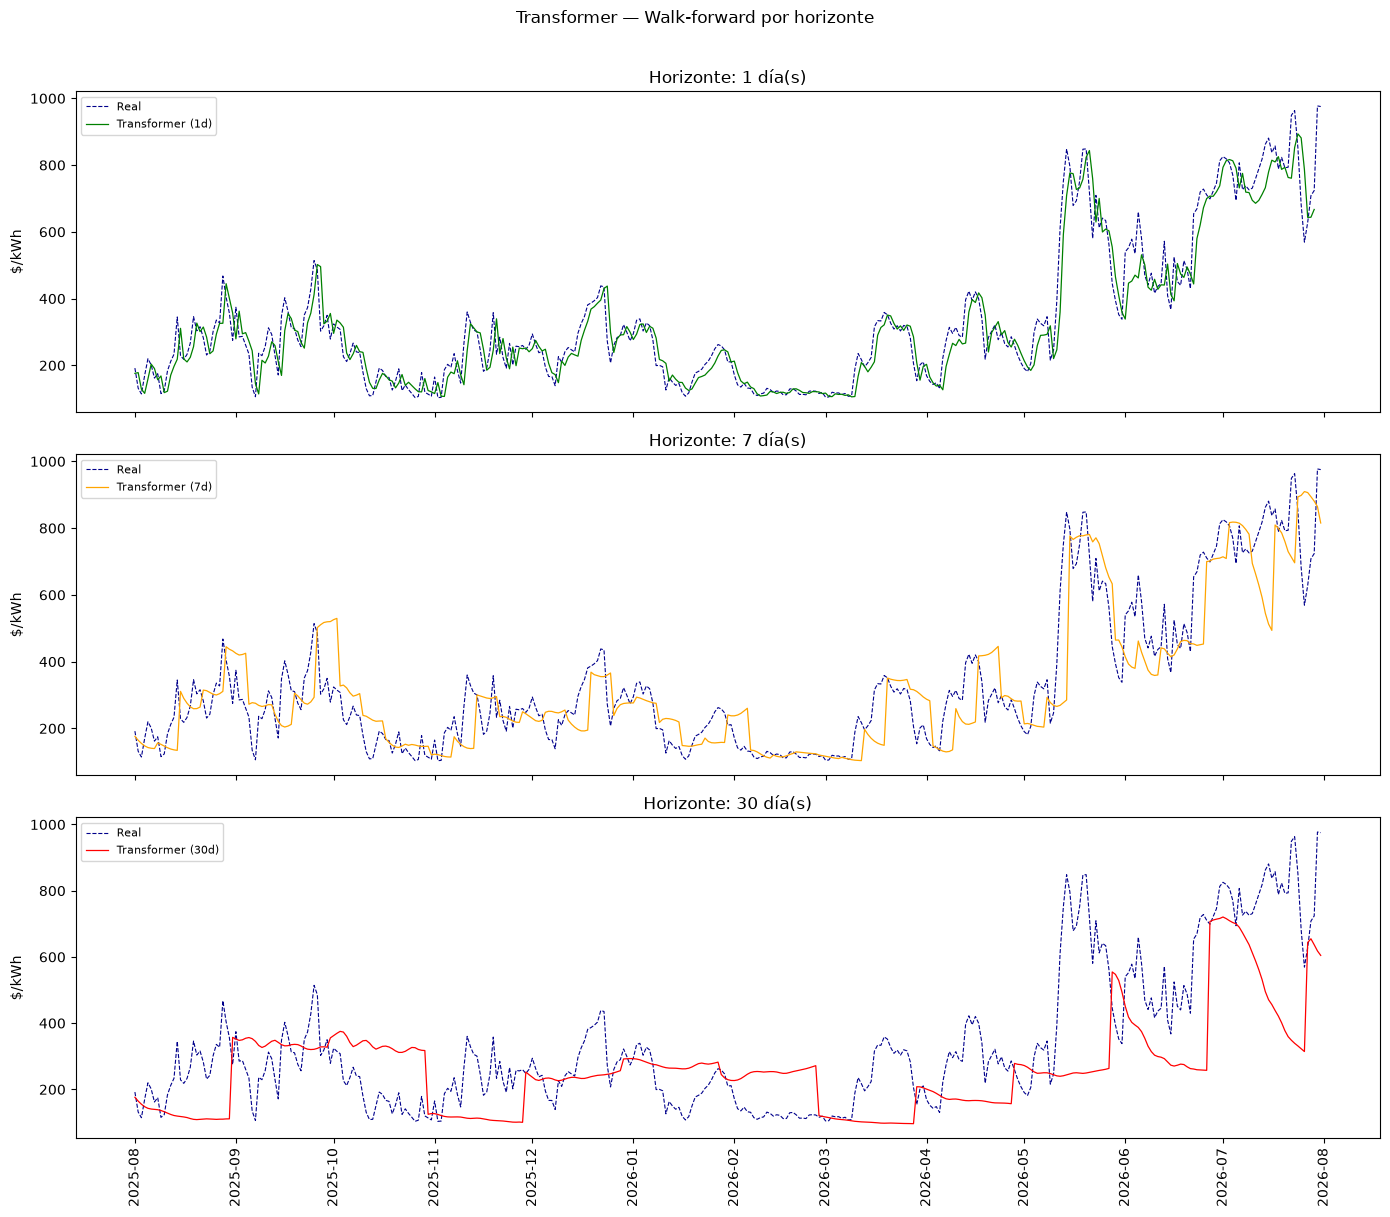

In [12]:
fig, axes = plt.subplots(3, 1, figsize=(14, 12), sharex=True)
colores = {1: 'green', 7: 'orange', 30: 'red'}

for ax, h in zip(axes, [1, 7, 30]):
    ax.plot(test_data.index, test_data.values, color='darkblue', linewidth=0.8, linestyle='--', label='Real')
    pred = resultados_horizonte[h]
    ax.plot(pred.index, pred.values, color=colores[h], linewidth=0.9, label=f'Transformer ({h}d)')
    ax.set_ylabel('$/kWh')
    ax.set_title(f'Horizonte: {h} día(s)')
    ax.legend(fontsize=8)

axes[-1].tick_params(axis='x', rotation=90)
axes[-1].xaxis.set_major_locator(mdates.MonthLocator())
axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
fig.suptitle('Transformer — Walk-forward por horizonte', y=1.01)
plt.tight_layout()
plt.show()

Predicción de 30 días

In [13]:
# Combinar train + test escalados para tener el contexto completo hasta el último dato real
combined_scaled_futuro = np.concatenate([train_scaled, test_scaled])

contexto_futuro = combined_scaled_futuro[-input_window:]
pred_futuro_scaled = forecast_block(model, contexto_futuro, pasos=30)

pred_futuro = scaler.inverse_transform(np.array(pred_futuro_scaled).reshape(-1, 1)).flatten()
fechas_futuro = pd.date_range(test_data.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')

pred_futuro_transformer = pd.Series(pred_futuro, index=fechas_futuro)

print(f"Forecast Transformer: {fechas_futuro[0].date()} → {fechas_futuro[-1].date()}")
print(pred_futuro_transformer)

Forecast Transformer: 2026-08-01 → 2026-08-30
2026-08-01    858.254559
2026-08-02    839.039619
2026-08-03    837.953459
2026-08-04    825.973061
2026-08-05    801.475623
2026-08-06    774.599387
2026-08-07    755.082602
2026-08-08    739.451503
2026-08-09    723.883128
2026-08-10    704.559597
2026-08-11    684.852590
2026-08-12    676.650360
2026-08-13    683.078552
2026-08-14    695.382734
2026-08-15    704.085334
2026-08-16    703.721302
2026-08-17    684.165564
2026-08-18    648.426430
2026-08-19    610.890971
2026-08-20    593.373266
2026-08-21    593.763909
2026-08-22    588.533687
2026-08-23    568.908911
2026-08-24    537.099230
2026-08-25    501.483570
2026-08-26    469.353168
2026-08-27    446.031983
2026-08-28    435.625029
2026-08-29    435.598781
2026-08-30    426.412432
Freq: D, dtype: float64


/var/folders/vz/dknzsyq13c55x4nb5c75hmn40000gn/T/ipykernel_1394/3977355727.py:8: DeprecationWarning: The 'generic' unit for NumPy timedelta is deprecated, and will raise an error in the future. This includes implicit conversion of bare integers (e.g. `+ 1`).Please use a specific unit instead.
  fechas_futuro = pd.date_range(test_data.index[-1] + pd.Timedelta(days=1), periods=30, freq='D')


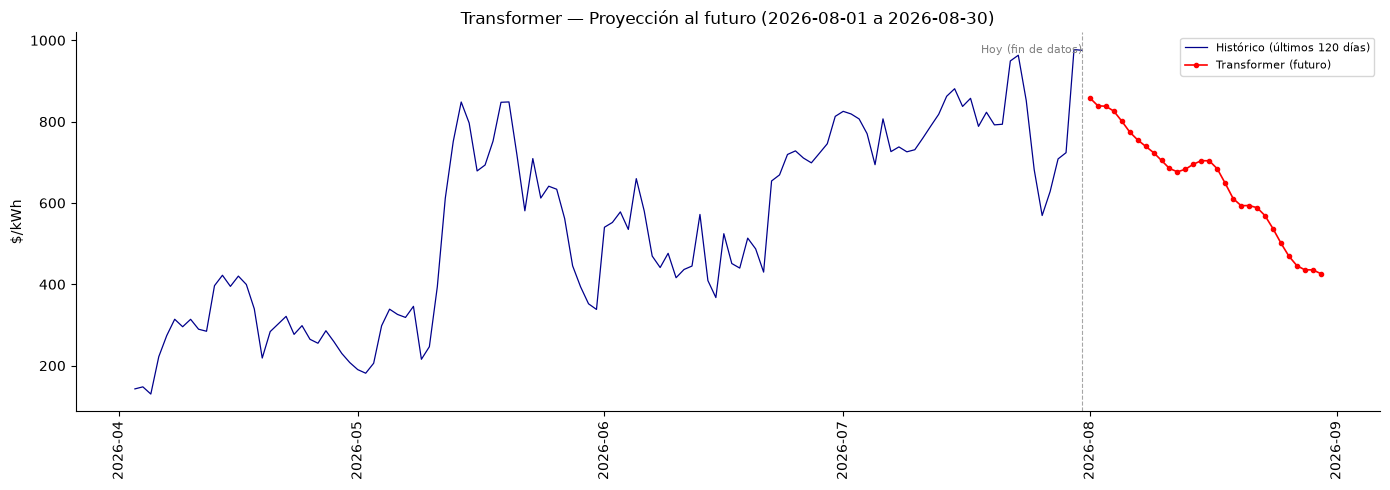

In [15]:
import seaborn as sns
fig, ax = plt.subplots(figsize=(14, 5))

serie_completa = pd.concat([train_data, test_data])
contexto_reciente = serie_completa[-120:]

ax.plot(contexto_reciente.index, contexto_reciente.values, color='darkblue', linewidth=0.9, label='Histórico (últimos 120 días)')
ax.plot(pred_futuro_transformer.index, pred_futuro_transformer.values, color='red', linewidth=1.2, marker='o', markersize=3, label='Transformer (futuro)')

ax.axvline(serie_completa.index[-1], color='gray', linestyle='--', linewidth=0.8, alpha=0.7)
ax.text(serie_completa.index[-1], ax.get_ylim()[1]*0.95, 'Hoy (fin de datos)', fontsize=8, color='gray', ha='right')

ax.set_ylabel('$/kWh')
ax.tick_params(axis='x', rotation=90)
ax.legend(fontsize=8)
ax.set_title(f'Transformer — Proyección al futuro ({fechas_futuro[0].date()} a {fechas_futuro[-1].date()})')
sns.despine()
plt.tight_layout()
plt.show()

guardar modelos

In [16]:
import joblib
raiz = encontrar_raiz_repo()
raiz.joinpath('models').mkdir(exist_ok=True)
torch.save(model.state_dict(), raiz / 'models' / 'transformer_state.pt')
joblib.dump(scaler, raiz / 'models' / 'transformer_scaler.pkl')
print("Modelo Transformer y scaler guardados")

Modelo Transformer y scaler guardados
